# Case Study: Analyzing Customer Behavior Using Fitbit Data to Improve Bellabeat’s Marketing Strategy



# Company Background
## About Bellabeat

Bellabeat is a high-tech manufacturer of health-focused smart products designed primarily for women. Although Bellabeat is a successful small company, it has strong potential to grow into a major player in the global smart device market.
Urška Sršen, co-founder and Chief Creative Officer, believes that analyzing smart device usage data can help identify new growth opportunities.

## Products

Bellabeat offers a range of smart wellness products:

- Bellabeat app: provides insights into activity,sleep,stress,menstrual cycle, and mindfulness habits.
- leaf: A wearable wellness tracker (bracelet, necklace, or clip) that tracks activity, sleep, and stress.
- Time: A smartwatch combining classic design with health tracking features.
- Spring: A smart water bottle that tracks daily hydration
- Bellabeat Membership: A subscription service offering personalized health and wellness guidance.  
    



# Business Task
In this case study, I focus on the Bellabeat app and analyze smart device data to understand how consumers use their devices.

The objective of this analysis is to:
- Identify trends in how users interact with smart devices using Fitbit data 
- Apply these insights to better understand Bellabeat app users 
- Provide data-driven recommendations to improve marketing strategies for the Bellabeat app 



# Data
## Data Sources
The dataset used in this analysis is:
FitBit Fitness Tracker Data (CC0: Public Domain, available via Kaggle/Mobius)
- Contains data from 30 Fitbit users 
- Includes activity, steps, calories, and sleep tracking 
- For this case study, the following files were used: 
	- dailyActivity_merged.csv 
	- sleepDay_merged.csv 
 ## Limitations:	
- Small sample size (30 users) 
- Data collected from Fitbit users, not Bellabeat users 
- Lack of demographic information. 
 These limitations may affect the generalizability of the findings. Future analysis could incorporate larger and more representative datasets.


# libraries
Due to the size of the dataset, we used Python for data manipulation and analysis of this case study. We imported the necessary  libraries for the task.

In [1]:
import numpy as np
import pandas as pd

# Data Loading
we load Fitbit datasets to begin analysis of user behaviour patterns.


In [2]:
activity = pd.read_csv("dailyActivity_merged.csv")
sleep = pd.read_csv("sleepDay_merged.csv")

# Data understanding

In [3]:
from IPython.display import display

display(activity.head())
display(sleep.head())

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [4]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [5]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


#  Data Cleaning and Preparation

The following steps were performed:
- Verified and corrected data types (e.g., date formatting) 
- checked for missing and duplicate values 
- Created new features such as day of the week and sleep category 
- Explored data using sorting and grouping techniques 
- Merged activity and sleep datasets for deeper analysis. 
These steps ensured the dataset was clean and ready for analysis

In [6]:
activity.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [7]:
sleep.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [8]:
activity.duplicated().sum()

np.int64(0)

In [9]:
sleep.duplicated().sum() 

np.int64(3)

Both the activity and sleep datasets were checked for missing and duplicate values using .isnull().sum() and .duplicated().sum(), respectively. The results indicate that there are no missing (NaN) values or duplicate records in either dataset, suggesting a high level of data completeness and consistency.”

In [10]:
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
activity["DayofWeek"] =activity["ActivityDate"].dt.day_name()

In [11]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        457 non-null    int64         
 1   ActivityDate              457 non-null    datetime64[ns]
 2   TotalSteps                457 non-null    int64         
 3   TotalDistance             457 non-null    float64       
 4   TrackerDistance           457 non-null    float64       
 5   LoggedActivitiesDistance  457 non-null    float64       
 6   VeryActiveDistance        457 non-null    float64       
 7   ModeratelyActiveDistance  457 non-null    float64       
 8   LightActiveDistance       457 non-null    float64       
 9   SedentaryActiveDistance   457 non-null    float64       
 10  VeryActiveMinutes         457 non-null    int64         
 11  FairlyActiveMinutes       457 non-null    int64         
 12  LightlyActiveMinutes  

The ‘ActivityDate’ column was converted to datetime format to ensure proper time-based analysis. Additionally, a new feature ‘DayofWeek’ was created, enabling the exploration of user activity trends across different days of the week.



In [12]:
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"], errors="coerce")

In [13]:
sleep["SleepDay"] = pd.to_datetime(
    sleep["SleepDay"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="raise"
)

In [14]:
bad_dates = sleep[pd.to_datetime(sleep["SleepDay"], errors="coerce").isna()]
bad_dates

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed


In [15]:
sleep.dtypes

Id                             int64
SleepDay              datetime64[ns]
TotalSleepRecords              int64
TotalMinutesAsleep             int64
TotalTimeInBed                 int64
dtype: object

In [16]:
activity.dtypes

Id                                   int64
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
DayofWeek                           object
dtype: object

In [17]:
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

In [18]:
sleep.info()
sleep.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  413 non-null    int64         
 1   SleepDay            413 non-null    datetime64[ns]
 2   TotalSleepRecords   413 non-null    int64         
 3   TotalMinutesAsleep  413 non-null    int64         
 4   TotalTimeInBed      413 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 16.3 KB


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


In [19]:
sleep= sleep.drop_duplicates()

In [20]:
sleep.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [21]:
activity.dtypes
sleep.dtypes

Id                             int64
SleepDay              datetime64[ns]
TotalSleepRecords              int64
TotalMinutesAsleep             int64
TotalTimeInBed                 int64
dtype: object

In [22]:
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

In [23]:
sleep = sleep.copy()
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

In [24]:
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"]).dt.date
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"]).dt.date

In [25]:
activity_sleep_df = pd.merge(activity, sleep, left_on=["Id","ActivityDate"], right_on=["Id","SleepDay"])

In [26]:
activity_sleep_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayofWeek,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,224,0.14,0.14,0.0,0.0,0.0,0.13,0.0,0,0,9,32,50,Tuesday,2016-04-12,1,327,346
1,1927972279,2016-04-12,24,0.02,0.02,0.0,0.0,0.0,0.02,0.0,0,0,3,161,942,Tuesday,2016-04-12,3,750,775
2,2026352035,2016-04-12,1019,0.63,0.63,0.0,0.0,0.0,0.63,0.0,0,0,64,223,600,Tuesday,2016-04-12,1,503,546
3,3977333714,2016-04-12,759,0.57,0.57,0.0,0.0,0.0,0.57,0.0,0,0,17,187,182,Tuesday,2016-04-12,1,274,469
4,4020332650,2016-04-12,8,0.01,0.01,0.0,0.0,0.0,0.01,0.0,0,0,1,321,446,Tuesday,2016-04-12,1,501,541


Sleep duration was categorized into low, medium, and high groups using manually defined thresholds after merging the activity and sleep datasets for exploratory analysis.



In [27]:
activity_sleep_df['sleep_category'] = pd.cut(
activity_sleep_df['TotalMinutesAsleep'],
bins=[0, 300, 420, 600, 1000],
labels=['Very Low', 'Low', 'Normal', 'High']

)


# Analysis                                                                                                              
The following analysis explores user behavior patterns based on activity, sleep, and sedentary data.

### Activity patterns by Day of Week


In [28]:
activity.groupby("DayofWeek")["TotalSteps"].mean()

DayofWeek
Friday       6737.561644
Monday       7118.588235
Saturday     7089.773333
Sunday       6058.013889
Thursday     6847.083333
Tuesday      4914.917808
Wednesday    7510.708333
Name: TotalSteps, dtype: float64

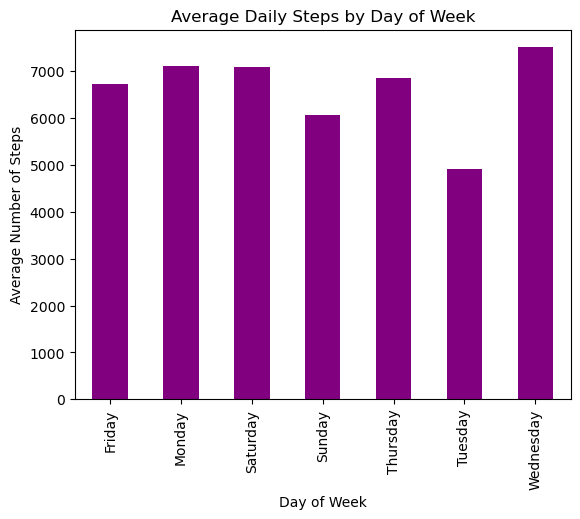

In [29]:
import matplotlib.pyplot as plt

activity.groupby("DayofWeek")["TotalSteps"].mean().plot(kind='bar',color="purple")

plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Steps")

plt.show()

The analysis shows that user activity varies across the week. The highest average step count occurs on Wednesdays (≈7,510 steps), while the lowest is observed on Tuesdays (≈4,915 steps).
This indicates higher activity levels in the middle of the week compared to other days possibly due to work schedules or rest behavior (e.g., weekends).



## Activity and Calorie Burn Analysis

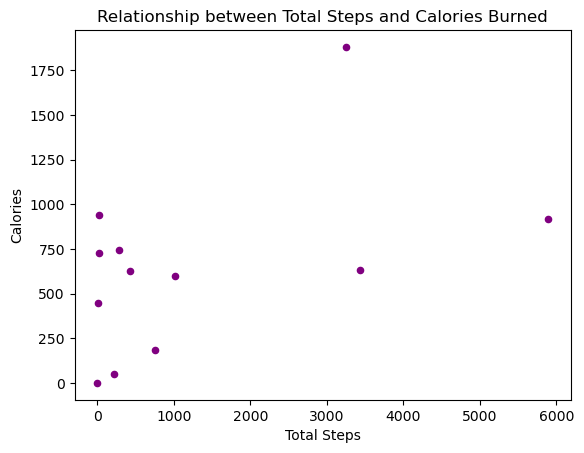

In [30]:
import matplotlib.pyplot as plt

activity_sleep_df.plot.scatter(x='TotalSteps', y='Calories',color='purple')

plt.title("Relationship between Total Steps and Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories")

plt.show()

In [31]:
activity_sleep_df[['TotalSteps', 'Calories', 'SedentaryMinutes', 'TotalMinutesAsleep']].corr()

,TotalSteps,Calories,SedentaryMinutes,TotalMinutesAsleep
TotalSteps,1.000000,0.487397,-0.302119,-0.341252
Calories,0.487397,1.000000,-0.307728,0.123807
SedentaryMinutes,-0.302119,-0.307728,1.000000,-0.017384
TotalMinutesAsleep,-0.341252,0.123807,-0.017384,1.000000



There is a moderate positive relationship between total steps and calories burned, with a correlation of 0.48. This indicates that increased physical activity generally leads to higher energy expenditure.
However, several inconsistencies were observed:
- Some users recorded zero or nearly zero steps but still burned 500–1000 calories, likely due to basal metabolic rate and non-step-related    activity. 
- Some high-step users showed relatively low calorie burn, and others with very high calorie burn showed medium amount of steps which may be influenced by individual differences such as metabolism, body composition, or tracking inaccuracies. 
Overall, while steps contribute significantly to calorie burn, they are not the sole determinant.


## Sleep and Activity Analysis

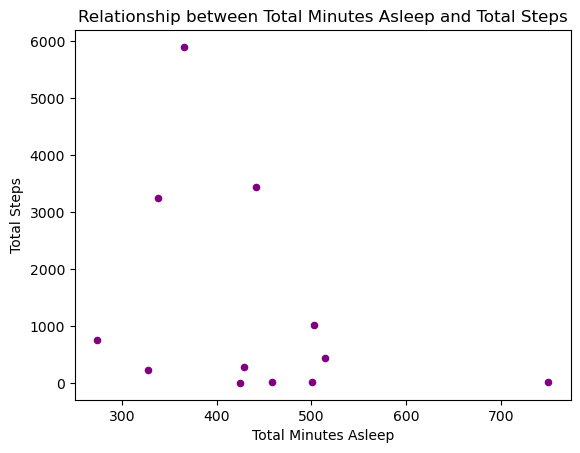

In [32]:
import matplotlib.pyplot as plt

activity_sleep_df.plot.scatter(x='TotalMinutesAsleep', y='TotalSteps',color='purple')

plt.title("Relationship between Total Minutes Asleep and Total Steps")
plt.xlabel("Total Minutes Asleep")
plt.ylabel("Total Steps")

plt.show()

There is a weak negative correlation (-0.34) between total minutes asleep and total steps, indicating no strong relationship between sleep duration and physical activity
Users show highly mixed behavior:
- Some with high sleep duration recorded very low activity. 
- Others with moderate sleep levels showed higher activity. 
This indicates that sleep duration alone is not a reliable predictor of physical activity. Lifestyle factors such as work schedules, habits, and personal routines likely play a larger role. Some extreme values may also indicate missing or incomplete tracking data

## Sleep and Sedentary Behavior Analysis

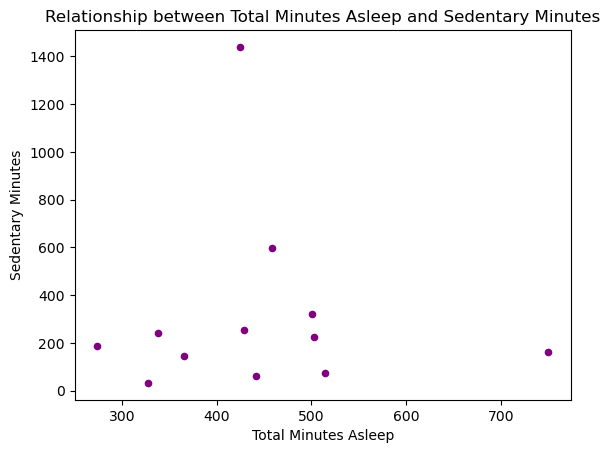

In [33]:
import matplotlib.pyplot as plt

activity_sleep_df.plot.scatter(x='TotalMinutesAsleep',y='SedentaryMinutes',color='purple')

plt.title("Relationship between Total Minutes Asleep and Sedentary Minutes")
plt.xlabel("Total Minutes Asleep")
plt.ylabel("Sedentary Minutes")

plt.show()

There is no meaningful relationship between sleep duration and sedentary behavior (correlation: -0.01).
Findings show inconsistent patterns:
- Users with low sleep sometimes still had low sedentary time. 
- Users with long sedentary time showed only moderate sleep duration. 
- Users with higher sleep did not consistently show lower sedentary behavior. 
This indicates that sleep duration does not meaningfully predict sedentary behavior.



## Visual summary 

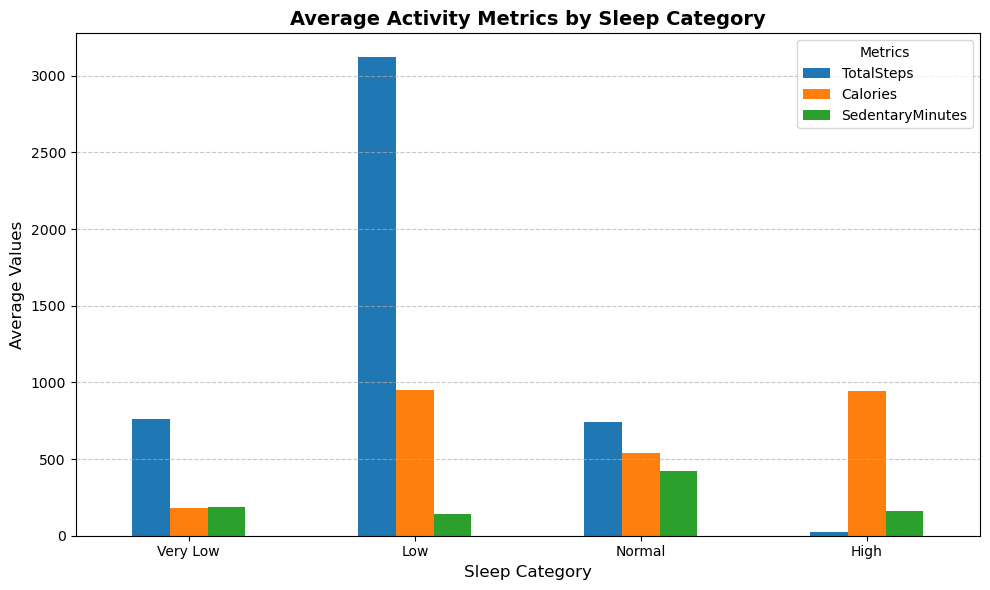

In [34]:
import matplotlib.pyplot as plt

grouped = activity_sleep_df.groupby('sleep_category', observed=False)[
    ['TotalSteps', 'Calories', 'SedentaryMinutes']
].mean()

ax = grouped.plot(kind='bar', figsize=(10,6))

plt.title('Average Activity Metrics by Sleep Category', fontsize=14, weight='bold')
plt.xlabel('Sleep Category', fontsize=12)
plt.ylabel('Average Values', fontsize=12)

plt.xticks(rotation=0)
plt.legend(title='Metrics')


plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This visualization summarizes average activity metrics across sleep categories. While it does not introduce new findings, it reinforces previously observed patterns and provides a clear comparison that is useful for business communication.



# Recommendations (Bellabeat Marketing Strategy)
  Based on the analysis, the following recommendations are made for Bellabeat:

- ## Target Low-Activity Days

  The Bellabeat app should implement personalized reminders and targeted challenges on low-activity days such as Tuesdays and Sundays. This       could help users maintain more consistent weekly activity levels.

- ## Use Multi-Metric Insights
  The app should avoid relying solely on sleep data for predictions or recommendations. Instead, combining steps, calories burned, and            sedentary time will provide more accurate and meaningful health insights.

- ## Promote Step-Based Engagement
  Since steps show a clear relationship with calorie burn and sedentary behavior, the app should encourage users to increase daily step counts    through:
     - Goal setting and streaks
     - Activity challenges 
     - Progress tracking and rewards


## Conclusion

This case study analyzed Fitbit fitness tracker data to generate insights that can support Bellabeat’s marketing strategy. Although the dataset is not sourced directly from Bellabeat users, it provides useful behavioral patterns related to physical activity, sleep habits, and calorie expenditure among wearable device users.

The analysis highlights opportunities for the Bellabeat app to improve user engagement through targeted interventions on low-activity days, improved sleep tracking consistency, and stronger motivation strategies linked to step-based activity goals.

These insights can help Bellabeat improve its product experience and develop more effective, data-driven features.


